In [2]:
from sklearn.datasets import load_diabetes
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [5]:
X,y = load_diabetes(return_X_y=True)

In [6]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [8]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [10]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.439933866156897

In [14]:
X_train.shape

(353, 10)

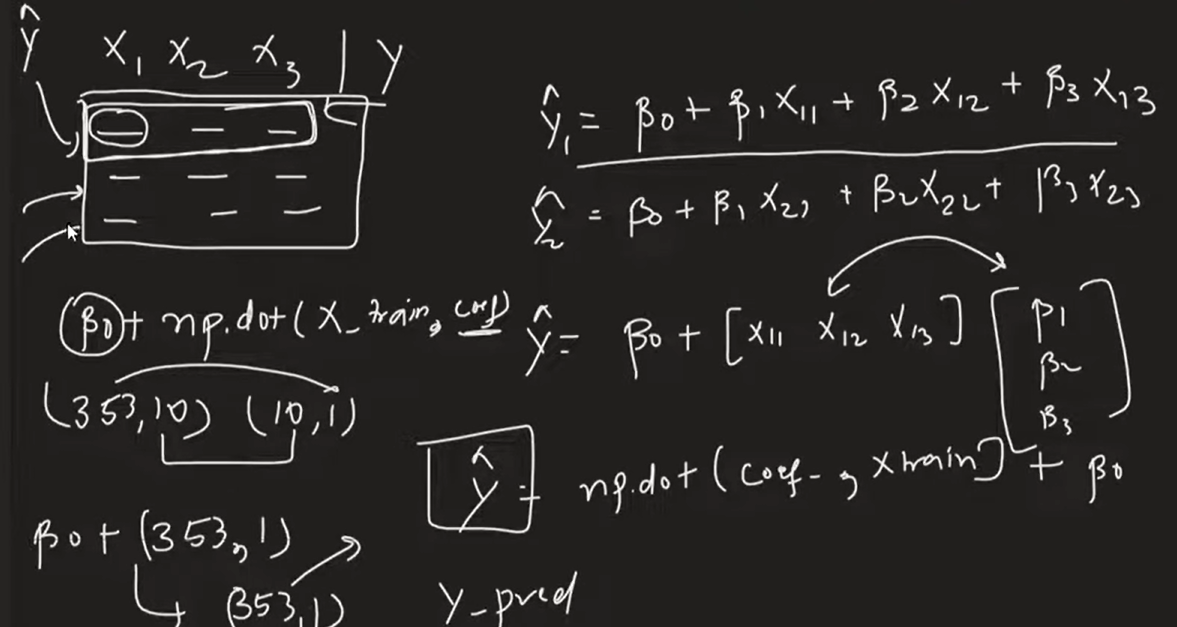

In [44]:
class GDRegressor:

    def __init__(self,learning_rate=0.01,epochs=100):
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X_train,y_train):
        # initialize your coefficient
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range (self.epochs):
            # update all the coefficient and the intercept
            # Vectorization
            y_hat = np.dot(X_train,self.coef_) + self.intercept_
            # print("shape of y hat:",y_hat.shape)
            intercept_der = -2 * np.mean(y_train-y_hat)
            self.intercept_ =self.intercept_ - (self.lr * intercept_der)

            coef_der = -2 * np.dot((y_train - y_hat),X_train)/X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_der)
            
        print(self.intercept_,self.coef_)
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [52]:
gdr = GDRegressor(epochs=1000,learning_rate=0.5)
gdr.fit(X_train,y_train)

152.01351687661833 [  14.38990585 -173.7235727   491.54898524  323.91524824  -39.32648042
 -116.01061213 -194.04077415  103.38135565  451.63448787   97.57218278]


In [53]:
y_pred = gdr.predict(X_test)
r2_score(y_test,y_pred)

0.4534503034722803